# Data from 20260708
 - Re-tested 14548R for all forces but only started recording sensor after 30s hold
    - can compare with previous results
 - Then tested 14548R for 2 min and 5 min holds at 100 N
    - can look at how metrics changed throughout hold
---
- Data from 20260904 at the very bottom

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from phd_helpers.experiments import parse_tekscan

In [2]:
a, b = 0.0066, 1.3803 # from moreCalibration.ipynb
frame_window = 5 # seconds for frame average

exp_path = Path('../../../LabData/contactTesting/20260708/14548R')

paths_retest = list(exp_path.glob('neu*.asm'))
path_2min = exp_path / '2minHold.asm'
path_5min = exp_path / '5minHold.asm'


# 2 and 5 minute hold data
header, (_, _, min2, _) = parse_tekscan(path_2min)
min5 = parse_tekscan(path_5min, 3)
SPF = float(header['SECONDS_PER_FRAME'])
print(round(min5.shape[0]*SPF / 60, 1), 'minute hold for min5')
print(round(min2.shape[0]*SPF / 60, 1), 'minute hold for min2')


def avg_frame(frames, start_time, window=5):
    n_frames = np.ceil(window / SPF).astype(int)
    start_frame = np.round(start_time / SPF).astype(int)
    end_frame = start_frame + n_frames
    return np.mean(frames[start_frame:end_frame+1], axis=0)

# 2 and 5 min data
start_2min = {100: avg_frame(min2, start_time=0, window=frame_window)}
mid_2min = {100: avg_frame(min2, start_time=45, window=frame_window)}
end_2min = {100: avg_frame(min2, start_time=90, window=frame_window)}

start_5min = {100: avg_frame(min5, start_time=0, window=frame_window)}
mid_5min = {100: avg_frame(min5, start_time=120, window=frame_window)}
end_5min = {100: avg_frame(min5, start_time=240, window=frame_window)}

# new test data
new_data = {}
for path in paths_retest:
    frame = avg_frame(parse_tekscan(path, 3), start_time=0, window=frame_window)
    F = int(path.name.replace('_1.asm', '')[3:])
    new_data[F] = frame
print('\nprevious test data loads: ', sorted(list(new_data.keys())))
retest_100N = parse_tekscan([x for x in paths_retest if '100' in x.name][0], sensor=3)

# previous test data
prev_paths = Path('../TekscanCalibration/moreCalibration')
prev_data = {int(path.name.split('-')[0]): np.loadtxt(path) for path in prev_paths.glob(f'*high1.txt')}
print('\nprevious test data loads: ', sorted(list(prev_data.keys())))

4.2 minute hold for min5
1.8 minute hold for min2

previous test data loads:  [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150]

previous test data loads:  [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]


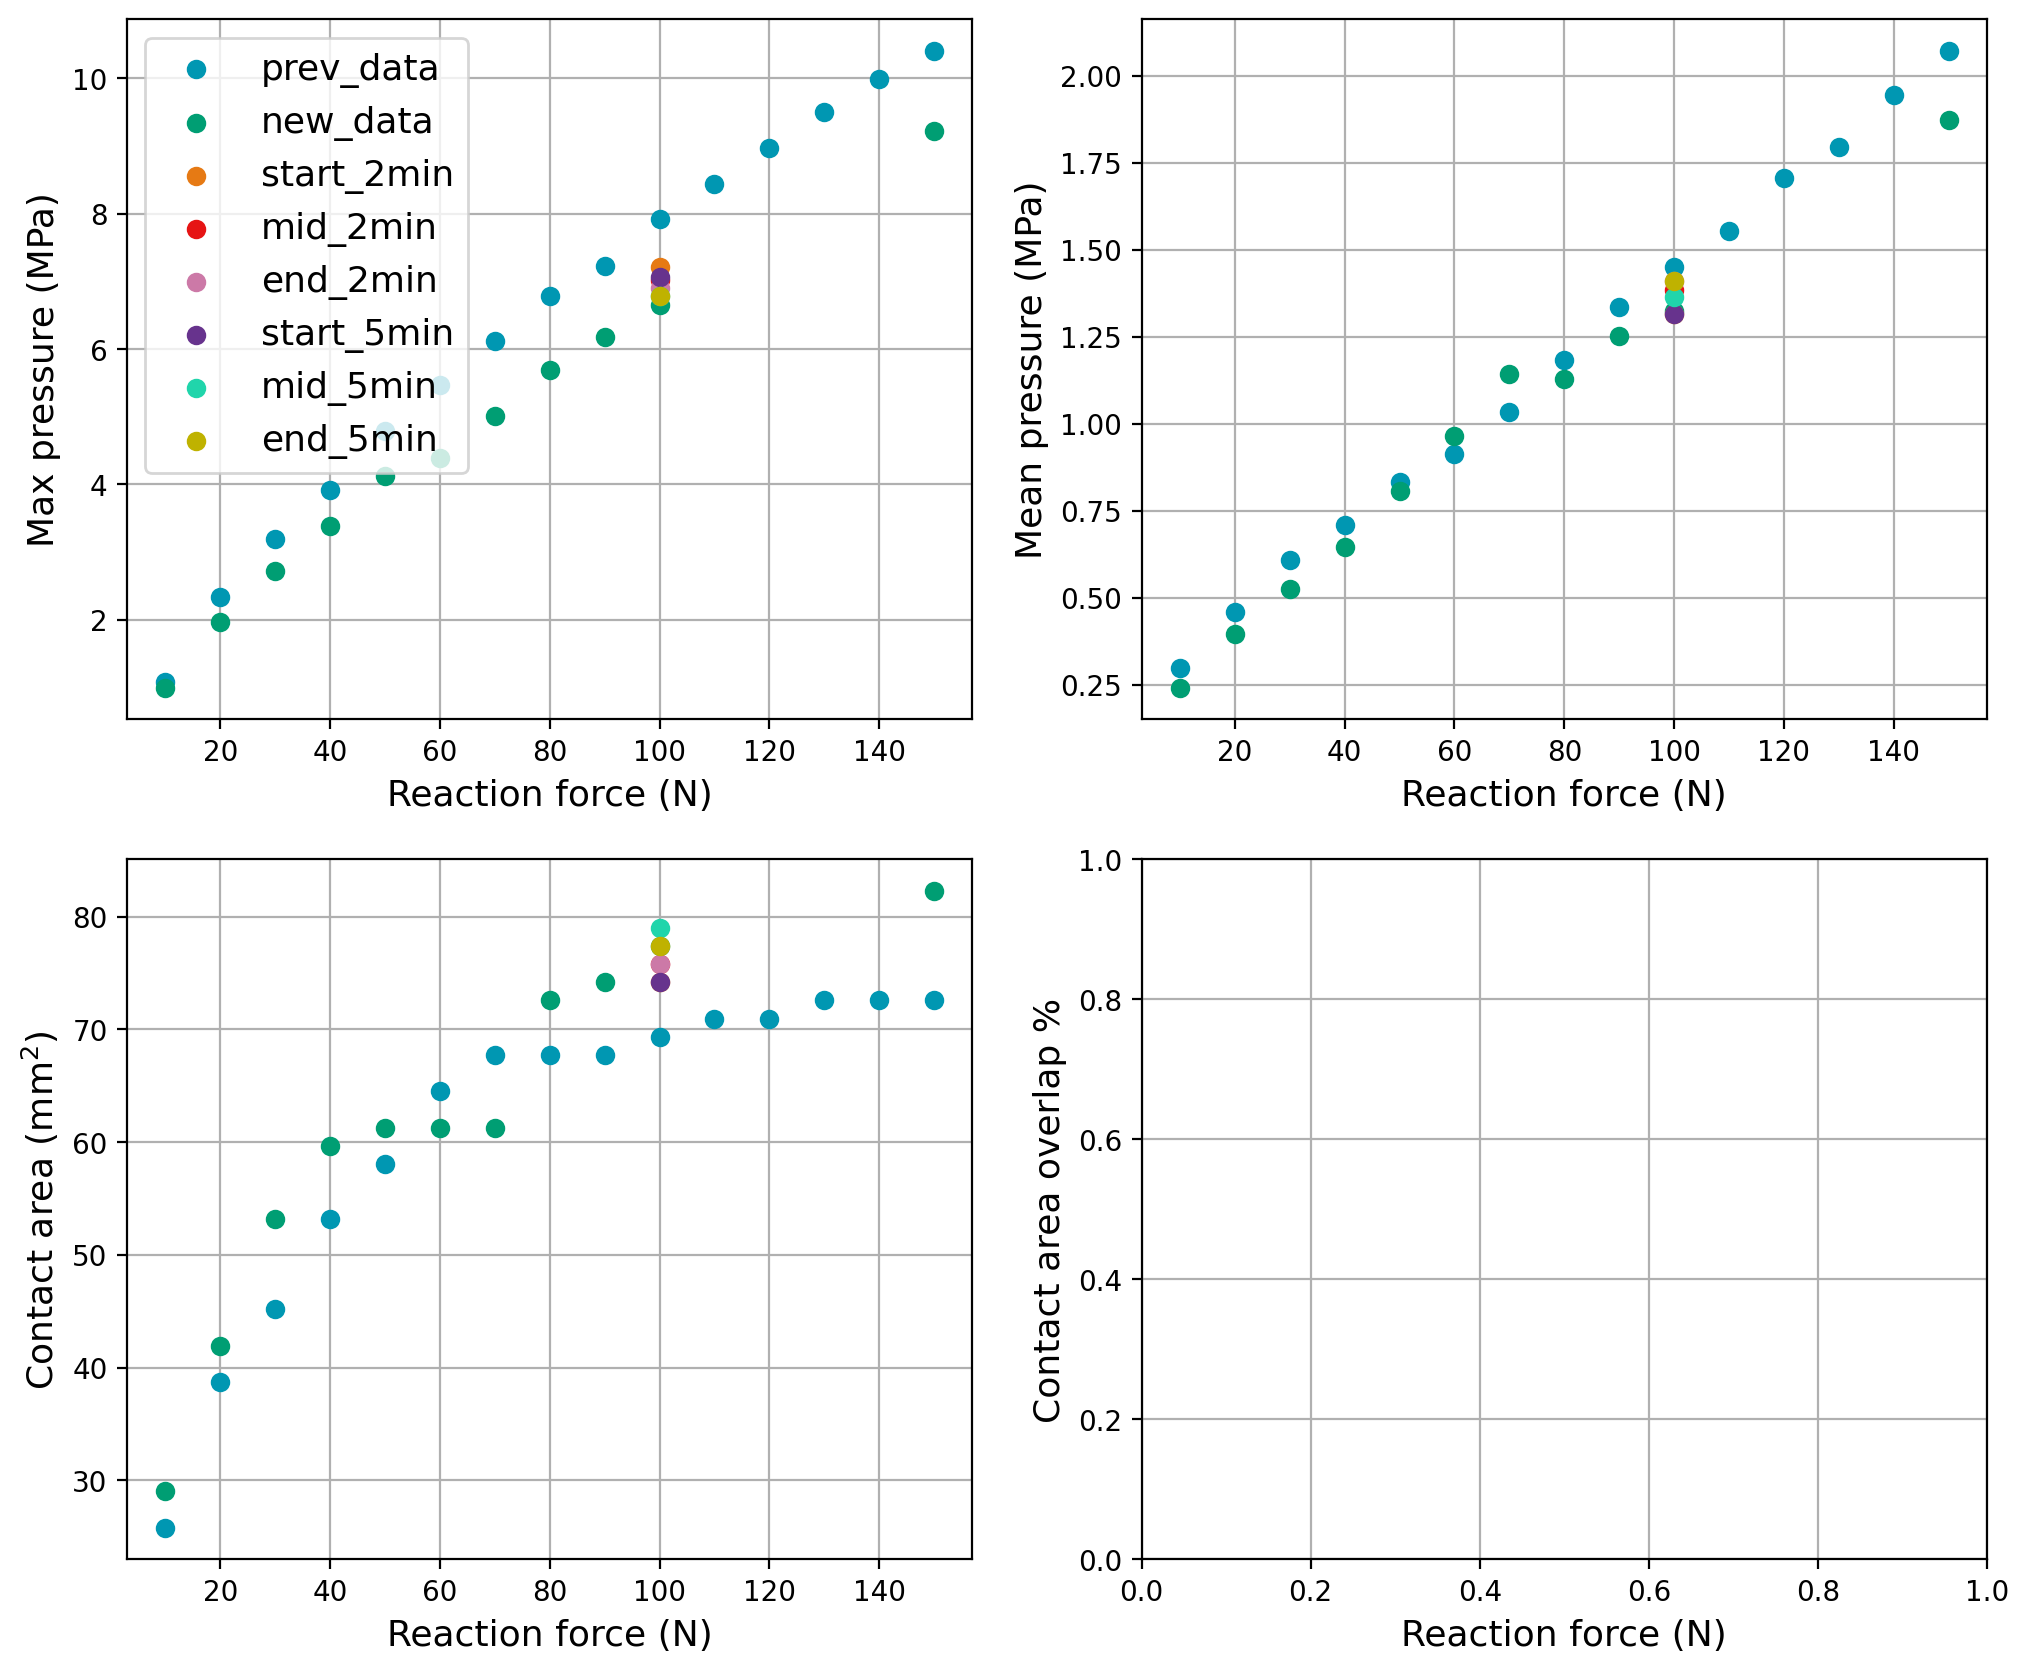

In [5]:
def compute_img_metrics(img, sensel_area=1.6129):

    CA = len(img[img>0]) * sensel_area
    # CA error - between 25% and 125% of the area of the boundary cells 
    # - plenty of cases that could exceed these limits but still reasonable limits I think...
    # - Given the nature of the contacting surfaces, it would be impossible for every boundary cell to be an edge case 
    # - so error bars based on those would give unreasonably wide range
    
    P_max = img.max()
    P_avg = img[img>0].mean()
    loc_Pmax = np.array(np.where(img==img.max())).ravel() # idx - (i, j)

    return {
        'CA': CA,
        'P_max': P_max,
        'P_avg': P_avg,
        'loc_Pmax': loc_Pmax
    }

nrows, ncols = 2, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*5), dpi=200)
ax = ax.flatten()


fs = 13
colors = {
    "prev_data" : "#0097b2",
    "new_data"  : "#009e73",
    "start_2min": "#e67a14",
    "mid_2min": "#e61414",
    'end_2min'  : "#cc79a7",
    'start_5min': "#67338d",
    'mid_5min': "#20d5ab",
    'end_5min'  : "#bfb200",
    }
markers = {
    "tek": "o", 
    "FE downscaled": "^",
    'FE raw': "^"
}

datas = [prev_data, new_data, start_2min, mid_2min, end_2min, start_5min, mid_5min, end_5min]
labels = ['prev_data', 'new_data', 'start_2min', 'mid_2min', 'end_2min', 'start_5min', 'mid_5min', 'end_5min']
for label, data in zip(labels, datas):
    for F, frame in data.items():
        if label != 'prev_data':
            frame = a*frame**b
        tek_mets = compute_img_metrics(frame)
        #print(tek_mets['loc_Pmax'])

        label_tek = label if F==100 else None
        ax[0].scatter(F, tek_mets['P_max'], c=colors[label], marker=markers['tek'], label=label_tek, zorder=2)
        ax[1].scatter(F, tek_mets['P_avg'], c=colors[label], marker=markers['tek'], zorder=2)
        ax[2].scatter(F, tek_mets['CA'], c=colors[label], marker=markers['tek'], zorder=2)
        #ax[2].errorbar(F, tek_mets['CA'], yerr=[[tek_mets['CA_e_low']], [tek_mets['CA_e_high']]] , c=colors['tek'], marker=markers['tek'], capsize=5, elinewidth=0.8)

ax[0].set_ylabel('Max pressure (MPa)', fontsize=fs)
ax[1].set_ylabel('Mean pressure (MPa)', fontsize=fs)
ax[2].set_ylabel('Contact area (mm$^2$)', fontsize=fs)
ax[3].set_ylabel('Contact area overlap %', fontsize=fs)
for ax_i in ax:
    ax_i.set_xlabel('Reaction force (N)', fontsize=fs)
    ax_i.grid()
ax[0].legend(fontsize=fs)
#ax[3].legend(fontsize=fs)
plt.show()

# Thoughts
 - shows that the max pressure can vary quite a bit (all used sensor 3)
    - could be due to hold length or just different day conditions
    - should definitely do mutiple repeats, maybe on different days
 - If holding till after compliance does reduce max pressure then it will also be the same for calibration, which will flatten the calibration curve and bring down max pressure even further
 - should definitely record the sensor results until most of compliance has gone
---
 - need to look at when that happens, in instron data
 - does removing compliance just spread out pressure concentration and then sensor drift affects all cells??

In [6]:
from phd_helpers.experiments import get_instron_data

def get_compliance(csv_path, F=100):        
    instron_data = get_instron_data(csv_path, zero_displacement=True)
    instron_data['force'] *= 1e3
    instron_data = instron_data[instron_data['force'].round(2)==F]
    instron_data['displacement'] -= instron_data['displacement'].iloc[0]
    instron_data['time'] -= instron_data['time'].iloc[0]
    return instron_data

def get_sensor_t(frames, start):
    return start + np.arange(frames.shape[0]) * SPF

In [78]:
exp_path = Path('../../../LabData/contactTesting/20260708/14548R')

csvs_retest = list(exp_path.glob('*_Exports/neu_*.csv'))
csv_2min = list(exp_path.glob('*_Exports/2min*.csv'))[0]
csv_5min = list(exp_path.glob('*_Exports/5min*.csv'))[0]

instron_retest_100N = get_compliance([x for x in csvs_retest if '_1_7' in x.name][0])
instron_2min = get_compliance(csv_2min)
instron_5min = get_compliance(csv_5min)

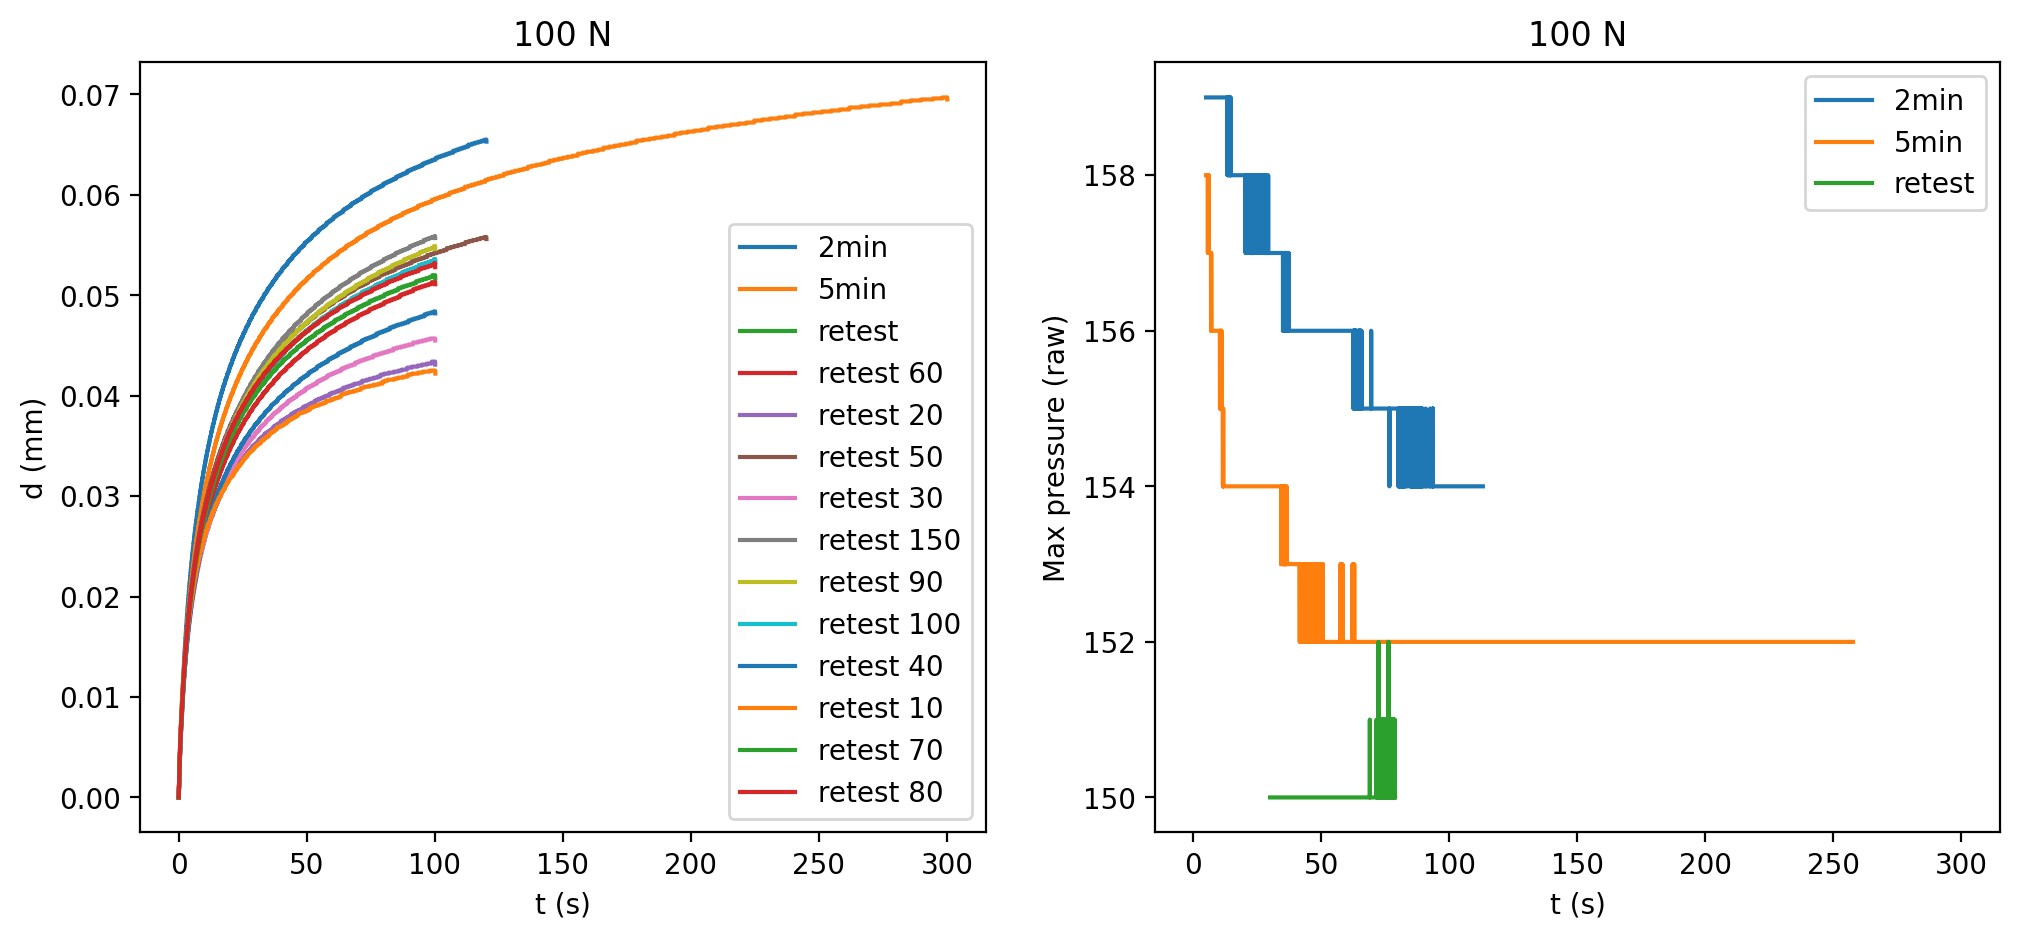

In [101]:
nrows, ncols = 1, 2 
fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*5), dpi=200)

ax[0].plot(instron_2min['time'], instron_2min['displacement'], label='2min')
ax[0].plot(instron_5min['time'], instron_5min['displacement'], label='5min')
ax[0].plot(instron_retest_100N['time'], instron_retest_100N['displacement'], label='retest')

ax[1].plot(get_sensor_t(min2, 5), np.max(min2, axis=(1, 2)), label='2min')
ax[1].plot(get_sensor_t(min5, 5), np.max(min5, axis=(1, 2)), label='5min')
ax[1].plot(get_sensor_t(retest_100N, 30), np.max(retest_100N, axis=(1, 2)), label=f'retest')

retest_order = [50, 150, 30, 10, 40, 90, 100, 80, 70, 20, 60]
for retest_csv in csvs_retest:
    F = retest_order[int(retest_csv.with_suffix('').name.split('_')[-1]) -1]
    retest = get_compliance(retest_csv, F=F)
    ax[0].plot(retest['time'], retest['displacement'], label=f'retest {F}')

ax[0].set_xlabel('t (s)')
ax[0].set_ylabel('d (mm)')
ax[0].set_title('100 N')
ax[0].legend()

ax[1].set_xlabel('t (s)')
ax[1].set_ylabel('Max pressure (raw)')
ax[1].set_title('100 N')
ax[1].legend()
ax[1].set_xlim(ax[0].get_xlim())

plt.show()

# Thoughts
 - Compliance affects max pressure
    - Need to wait almost 2 minutes for its effect to go
 - Get more compliance with greater force but rate also seems higher so all good after about 100s
 - Did I do them in order of: 2min, 5min, retest? - i.e. same order as decreasing max pressure - YES (checked)
   - if so, might show that it is important to condition the sensor before each set of testing. 
---
TURNS OUT THAT IT MIGHT HAVE BEEN TEMPERATURE THAT WAS HAVING THE DOMINANT EFFECT NOT CONDITIONING
- COMPLIANCE DOES ALSO MATTER SO STILL NEED TO HOLD for 60ish seconds
---
 - Below is max pressure plots for all the retest that were only recorded after at least 30 s hold
   - all fairly constant

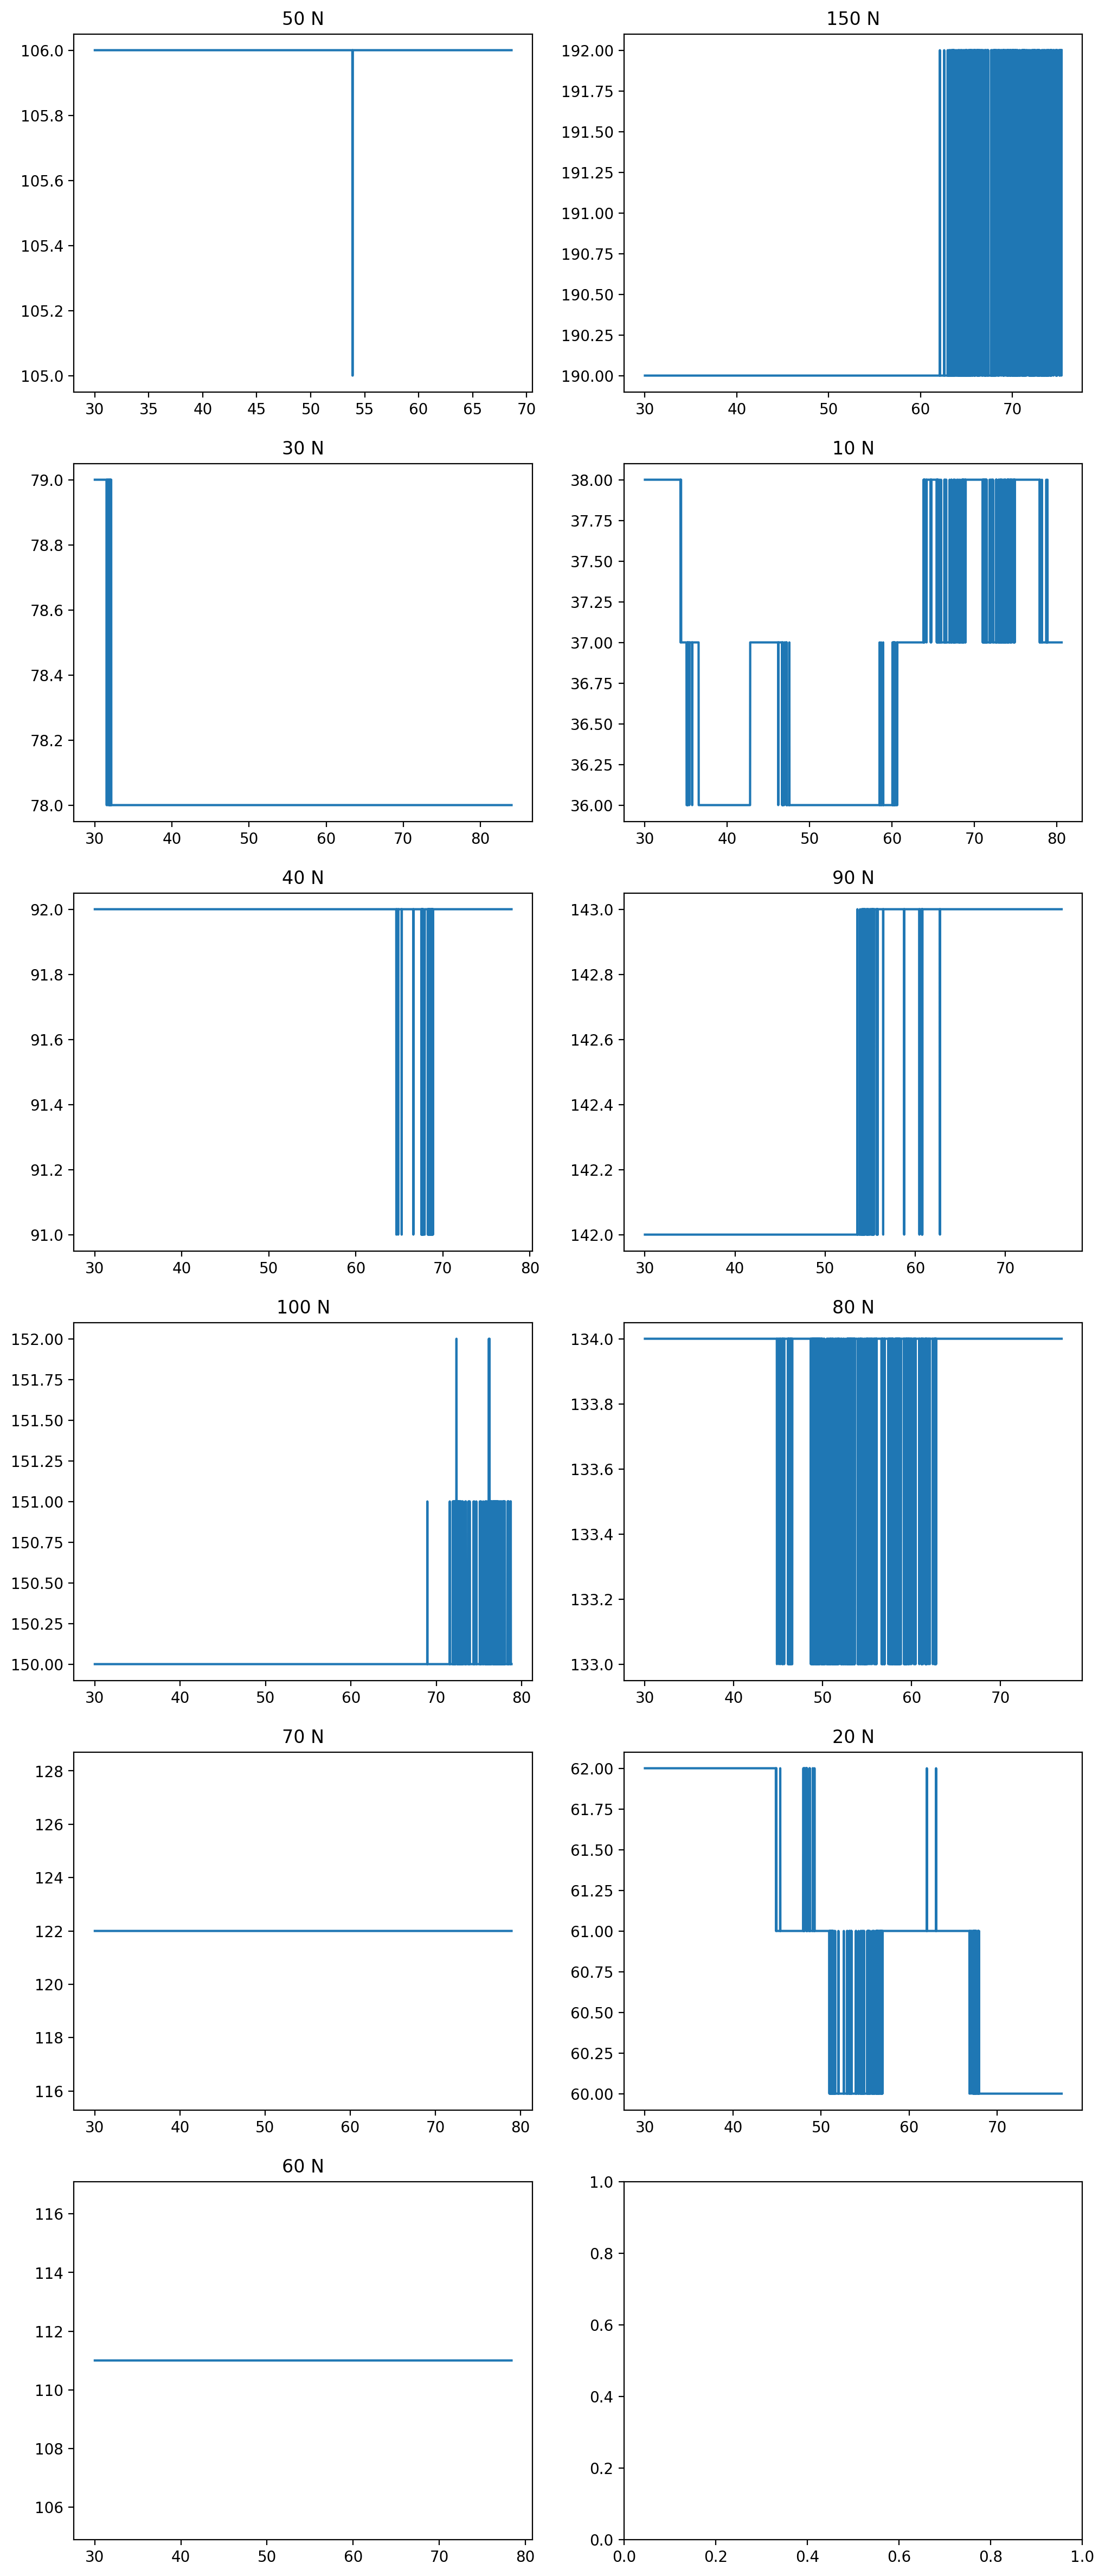

In [107]:
nrows, ncols = 6, 2 
fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*5), dpi=200)
ax = ax.flatten()

for i, F in enumerate(retest_order):
    retest = parse_tekscan([x for x in paths_retest if f'u{F}_' in x.name][0], sensor=3)
    ax[i].plot(get_sensor_t(retest, 30), np.max(retest, axis=(1, 2)), label=f'retest {F}')
    ax[i].set_title(f'{F} N')

In [110]:
other_paths = list(Path('../../../LabData/contactTesting/20260708/50017L').glob('*.asm'))
other_paths

[PosixPath('../../../LabData/contactTesting/20260708/50017L/neu20_1.asm'),
 PosixPath('../../../LabData/contactTesting/20260708/50017L/neu150_1.asm'),
 PosixPath('../../../LabData/contactTesting/20260708/50017L/neu40_1.asm'),
 PosixPath('../../../LabData/contactTesting/20260708/50017L/neu10_1.asm'),
 PosixPath('../../../LabData/contactTesting/20260708/50017L/neu30_1.asm'),
 PosixPath('../../../LabData/contactTesting/20260708/50017L/neu70_1.asm'),
 PosixPath('../../../LabData/contactTesting/20260708/50017L/neu100_1.asm'),
 PosixPath('../../../LabData/contactTesting/20260708/50017L/neu50_1.asm')]

In [114]:
np.max(parse_tekscan([x for x in other_paths if 'u10_' in x.name][0], sensor=3), axis=(1, 2))

array([39., 39., 39., ..., 40., 40., 40.], shape=(2732,))

# 20260904
 - Checking what compliance looks like with calibration blocks

In [ ]:
# these functions are from pipeline-box in fe_accuracy 20260904
def compute_hold_end_idx(frames):
    y = frames.sum(axis=(1, 2))
    return  np.argmin(np.gradient(np.gradient(y))) - 1
def compute_hold_start_idx(end_idx, hold_time, spf):
    n_frames = round(hold_time / spf)
    return max(0, end_idx - n_frames)

def get_hold_frames(frames, hold_time, spf, start_idx=None, end_idx=None):
    """Requires that tekscan sensor recording started before and ended after the hold period (with rapid-ish unloading)"""
    if end_idx is None:
        end_idx = compute_hold_end_idx(frames)
    if start_idx is None:
        start_idx = compute_hold_start_idx(end_idx, hold_time, spf)
    return frames[start_idx: end_idx+1]

In [17]:
exp_path = Path('../../../LabData/contactTesting/20260904')

cal_1_paths = list(exp_path.glob('calibration/cal_1*.asm'))
redos = [500, 700, 900]
redo_names = [f'cal_1_{x}Nredo.asm' for x in redos]
cal_1_paths = [x for x in cal_1_paths if x.name not in redo_names]
def F_from_path(path):
    return int(path.name.split('N')[0].split('_')[-1])
cal_1_Fs = [F_from_path(x) for x in cal_1_paths]
csvs_cal = list(exp_path.glob('calibration/cal_1*_Exports/cal_1_*.csv'))

In [22]:
sensor_id = 3
raw_mask = 0
custom_masks = [[4, -1, 0]] # [[raw_mask_value, j_idx, k_idx], ...]
hold_time = 180
avg_window = 5
cal_start_time = 55

cal_frames = {}
for f, cal_path in zip(cal_1_Fs, cal_1_paths):
    frames, spf = parse_tekscan(cal_path, sensor_id, return_spf=True)
    cal_frames[f] = get_hold_frames(frames, hold_time, spf)


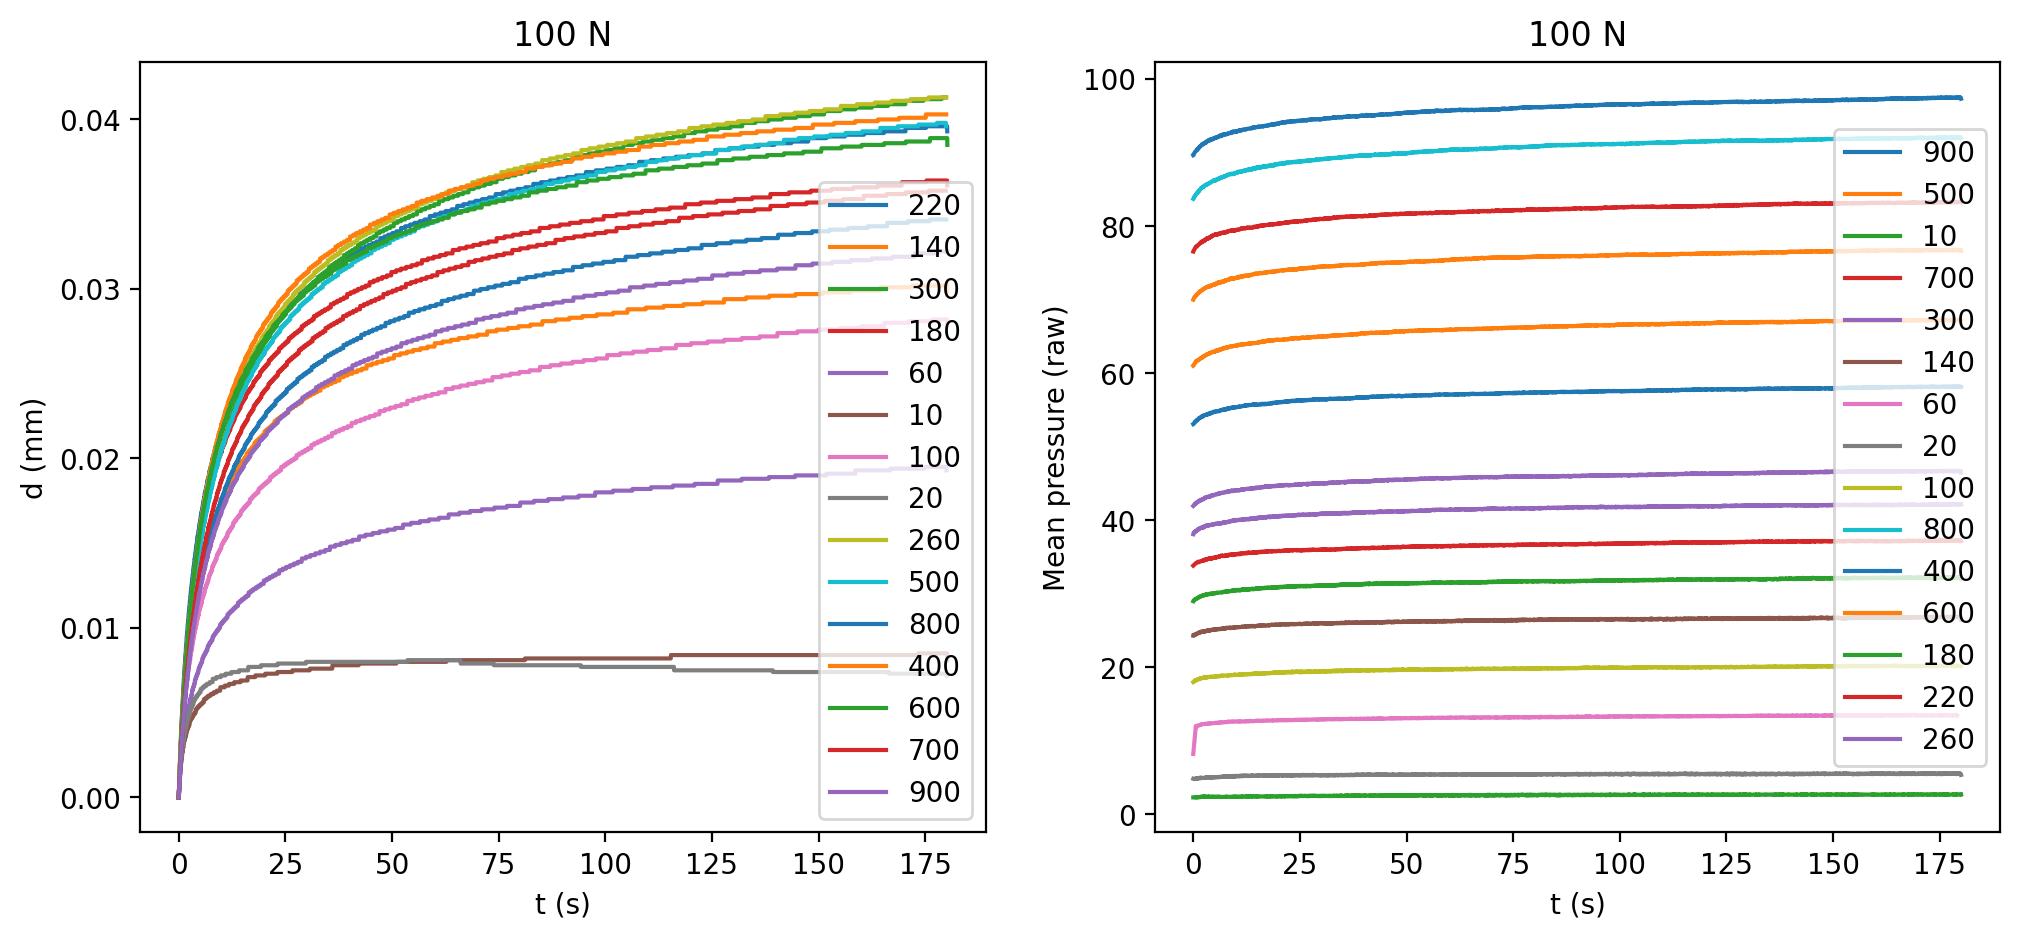

In [31]:
nrows, ncols = 1, 2 
fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*5), dpi=200)

cal_order = [60, 10, 100,  300, 180, 140, 220, 20, 260, 500, 800, 600, 400, 900, 700]
for csv in csvs_cal:
    F = cal_order[int(csv.with_suffix('').name.split('_')[-1]) -1]
    retest = get_compliance(csv, F=F)
    ax[0].plot(retest['time'], retest['displacement'], label=f'{F}')


for f, frames in cal_frames.items():
    spf = 1/16 if f != 60 else 0.1001
    ax[1].plot(spf*np.arange(frames.shape[0]), frames.mean(axis=(1, 2)), label=f'{f}')

ax[0].set_xlabel('t (s)')
ax[0].set_ylabel('d (mm)')
ax[0].set_title('100 N')
ax[0].legend()

ax[1].set_xlabel('t (s)')
ax[1].set_ylabel('Mean pressure (raw)')
ax[1].set_title('100 N')
ax[1].legend()
ax[1].set_xlim(ax[0].get_xlim())

plt.show()